In [2]:
import pandas as pd

# Loading the dataset
df = pd.read_csv("data/stud.csv")
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (1000, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Checking the data types and non-null counts of each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [4]:
# Checking for missing values
print(df.isnull().sum())

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


In [5]:
# Checking for any duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [6]:
# Checking the no. of unique values in each column
print(df.nunique())

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64


In [7]:
# Checking the statistical summary of the dataset
print(df.describe())

       math_score  reading_score  writing_score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [8]:
# Defining numerical and categorical columns
numerical_features = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in df.columns if df[col].dtype == 'str']

# print columns
print('We have {} numerical features : {}'.format(len(numerical_features), numerical_features))
print('We have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [9]:
# Unique categories in categorical columns
print(f"Categories in 'gender' column: {df['gender'].unique()}")
print("-"*70)
print(f"Categories in 'race/ethnicity' column: {df['race_ethnicity'].unique()}")
print("-"*70)
print(f"Categories in 'parental education' column: {df['parental_level_of_education'].unique()}")
print("-"*70)
print(f"Categories in 'lunch' column: {df['lunch'].unique()}")
print("-"*70)
print(f"Categories in 'test preparation course' column: {df['test_preparation_course'].unique()}")

Categories in 'gender' column: <StringArray>
['female', 'male']
Length: 2, dtype: str
----------------------------------------------------------------------
Categories in 'race/ethnicity' column: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
----------------------------------------------------------------------
Categories in 'parental education' column: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
----------------------------------------------------------------------
Categories in 'lunch' column: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
----------------------------------------------------------------------
Categories in 'test preparation course' column: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [10]:
# Adding new features total_score and average
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = round(df['total_score'] / 3, 2)
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


In [11]:
# Checking how many students scored full marks in each subject
print(f"Students with full marks in Math: {df[df['math_score'] == 100].shape[0]}")
print(f"Students with full marks in Reading: {df[df['reading_score'] == 100].shape[0]}")
print(f"Students with full marks in Writing: {df[df['writing_score'] == 100].shape[0]}")

Students with full marks in Math: 7
Students with full marks in Reading: 17
Students with full marks in Writing: 14


In [12]:
# Checking the number of students with less than 20 marks in each subject
print(f"Students with less than 20 marks in Math: {df[df['math_score'] < 20].shape[0]}")
print(f"Students with less than 20 marks in Reading: {df[df['reading_score'] < 20].shape[0]}")
print(f"Students with less than 20 marks in Writing: {df[df['writing_score'] < 20].shape[0]}")

Students with less than 20 marks in Math: 4
Students with less than 20 marks in Reading: 1
Students with less than 20 marks in Writing: 3


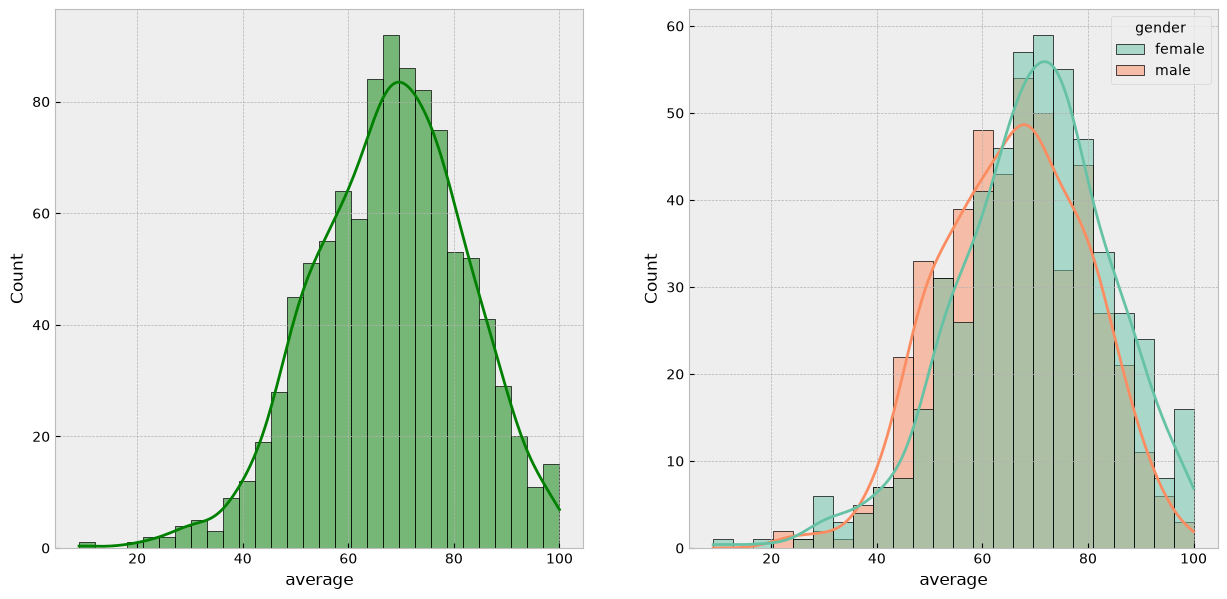

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the style for the plots
plt.style.use('bmh')

# Plotting the distribution of average scores
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g', edgecolor='black')

# plotting the distribution of average scores on the basis of gender
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='average', kde=True, hue='gender', palette='Set2', edgecolor='black')

plt.show()

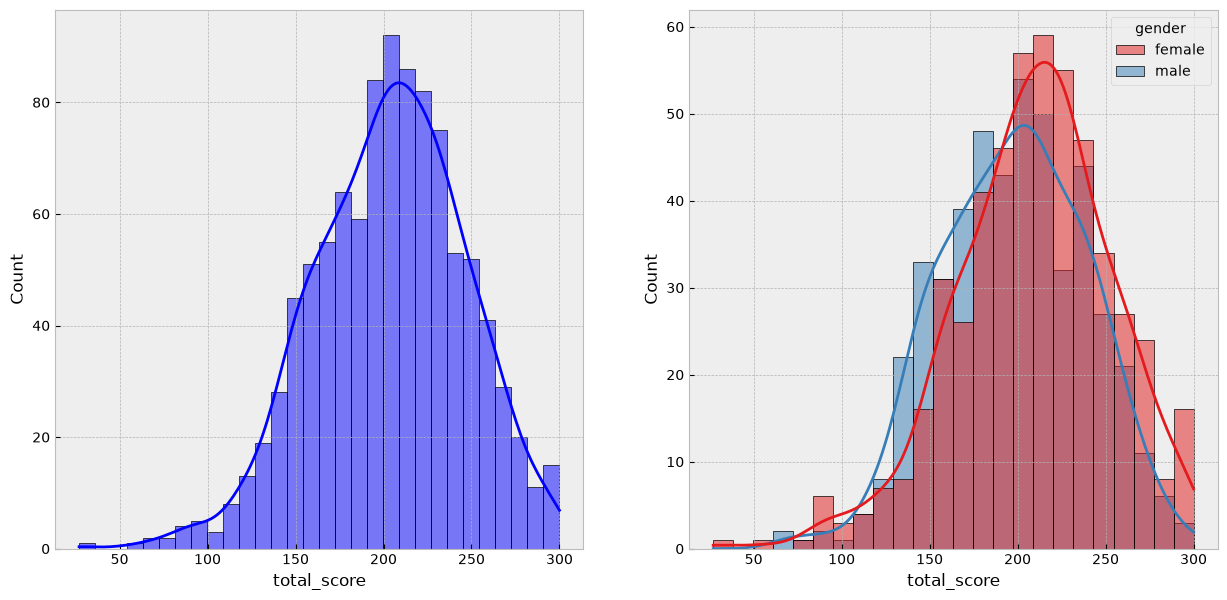

In [14]:
# Plotting the distribution of total scores
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='total_score', bins=30, kde=True, color='b', edgecolor='black')

# plotting the distribution of total scores on the basis of gender
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='total_score', kde=True, hue='gender', palette='Set1', edgecolor='black')
plt.show()

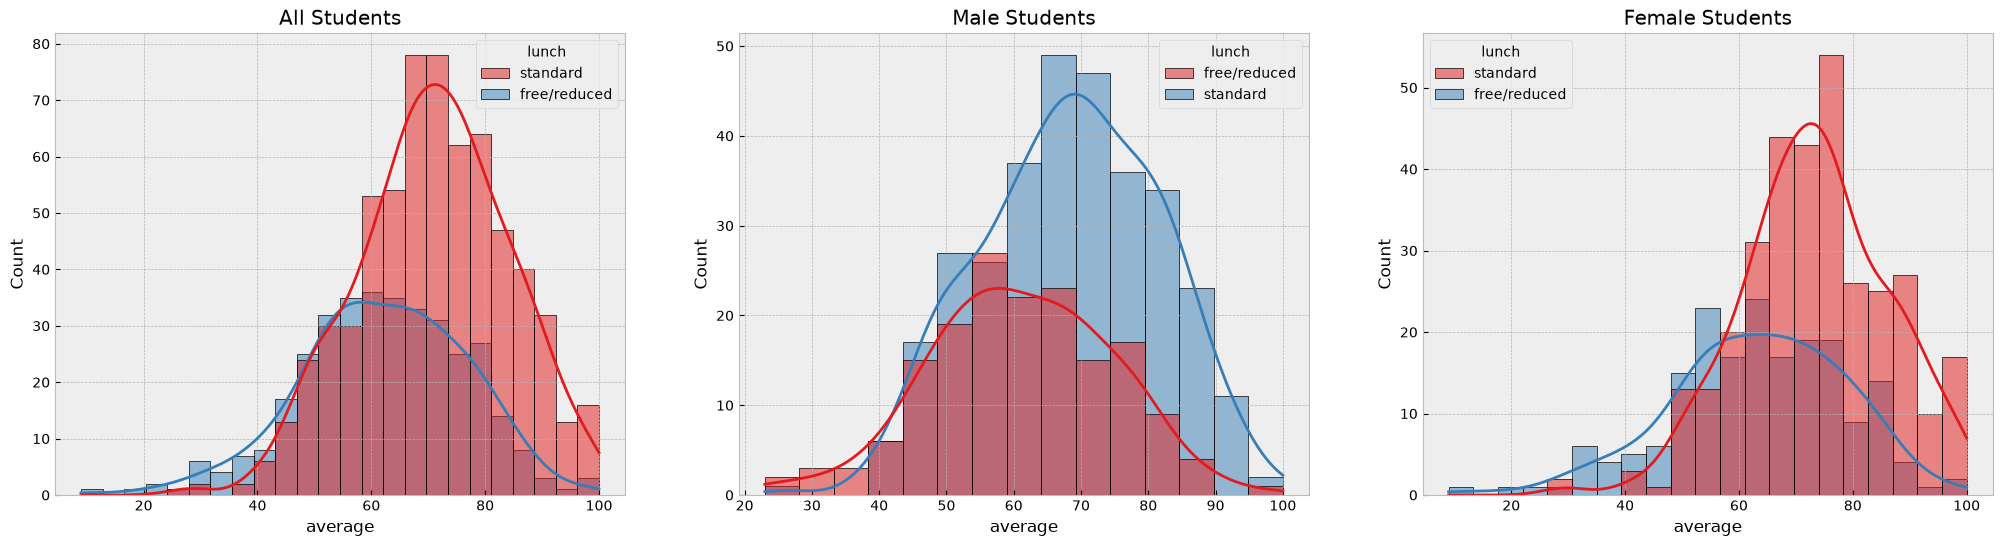

In [15]:
# Performance Comparison of students based on gender and lunch type in average scores
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

# For both genders
plt.subplot(1, 3, 1)
plt.title("All Students")
sns.histplot(data=df, x='average', kde=True, hue="lunch", edgecolor='black', palette='Set1')

# For male
plt.subplot(1, 3, 2)
plt.title("Male Students")
sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue="lunch", edgecolor='black', palette='Set1')

# For female
plt.subplot(1, 3, 3)
plt.title("Female Students")
sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue="lunch", edgecolor='black', palette='Set1')

plt.show()

## Insights
- A standard lunch helps students achieve good grades.
- Female students are performing better than the male students.

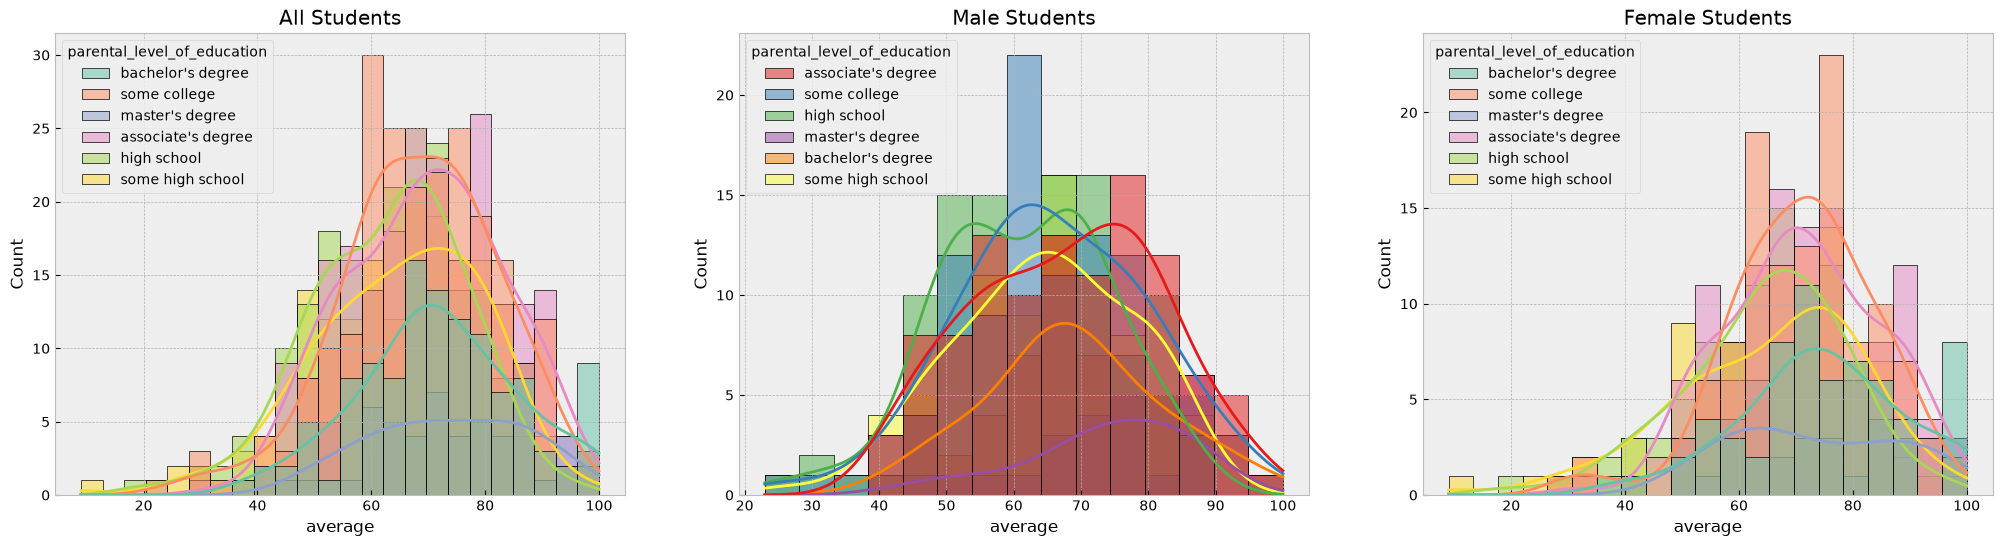

In [16]:
# Performance comparison of students on the basis of parental level of education in average scores
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

# For all students
plt.subplot(1, 3, 1)
plt.title('All Students')
ax = sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education', palette='Set2', edgecolor='black')

# For male students
plt.subplot(1, 3, 2)
plt.title('Male Students')
ax = sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='parental_level_of_education', palette='Set1', edgecolor='black')

# For female students
plt.subplot(1, 3, 3)
plt.title('Female Students')
ax = sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='parental_level_of_education', palette='Set2', edgecolor='black')

plt.show()

## Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

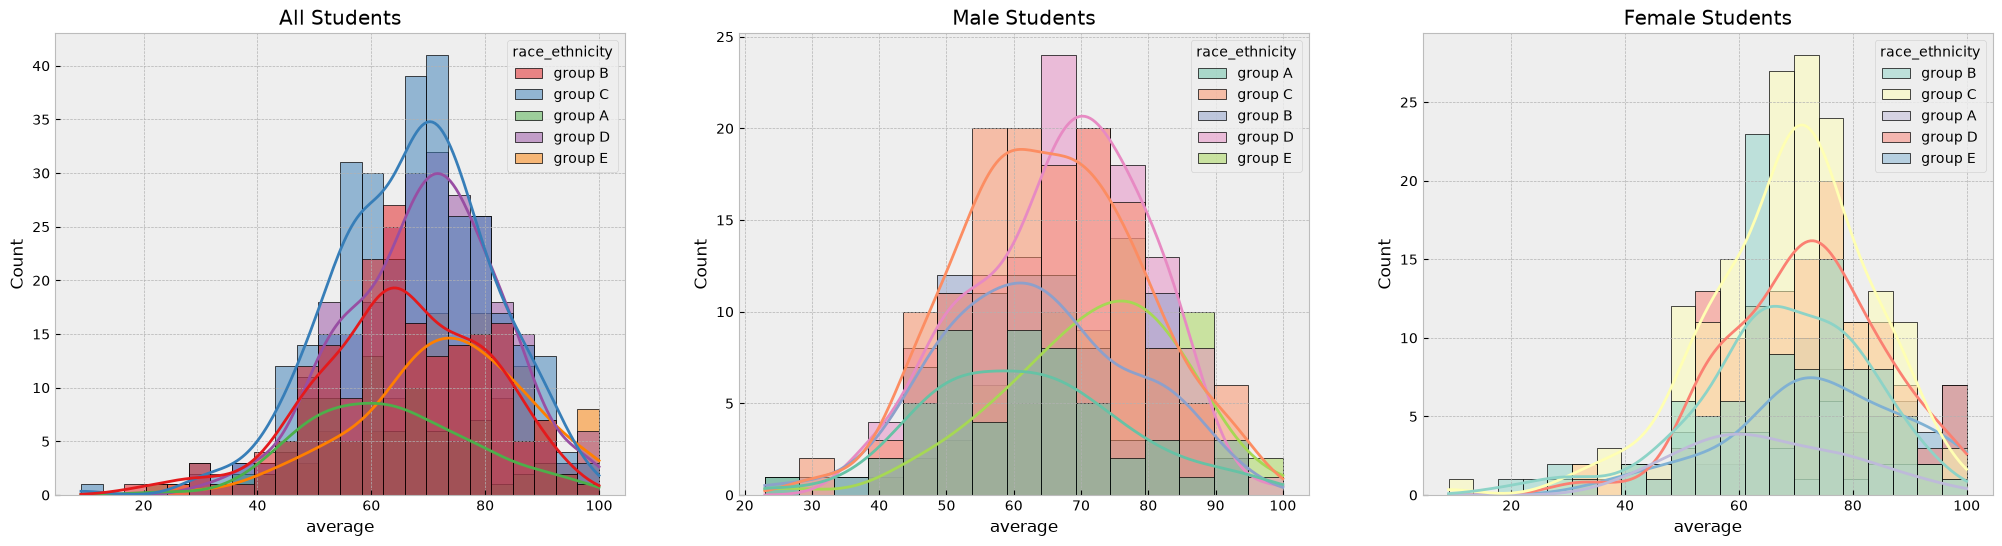

In [17]:
# Performance Comparison of students based on race/ethnicity in average scores for both genders
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

# For all students
plt.subplot(1, 3, 1)
plt.title('All Students')
ax = sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity', palette='Set1', edgecolor='black')

# For male students
plt.subplot(1, 3, 2)
plt.title('Male Students')
ax = sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='race_ethnicity', palette='Set2', edgecolor='black')

# For female students
plt.subplot(1, 3, 3)
plt.title('Female Students')
ax = sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='race_ethnicity', palette='Set3', edgecolor='black')

plt.show()

## Insights
- Students of group A and group B both perform poorly in exams irrespective of their gender.

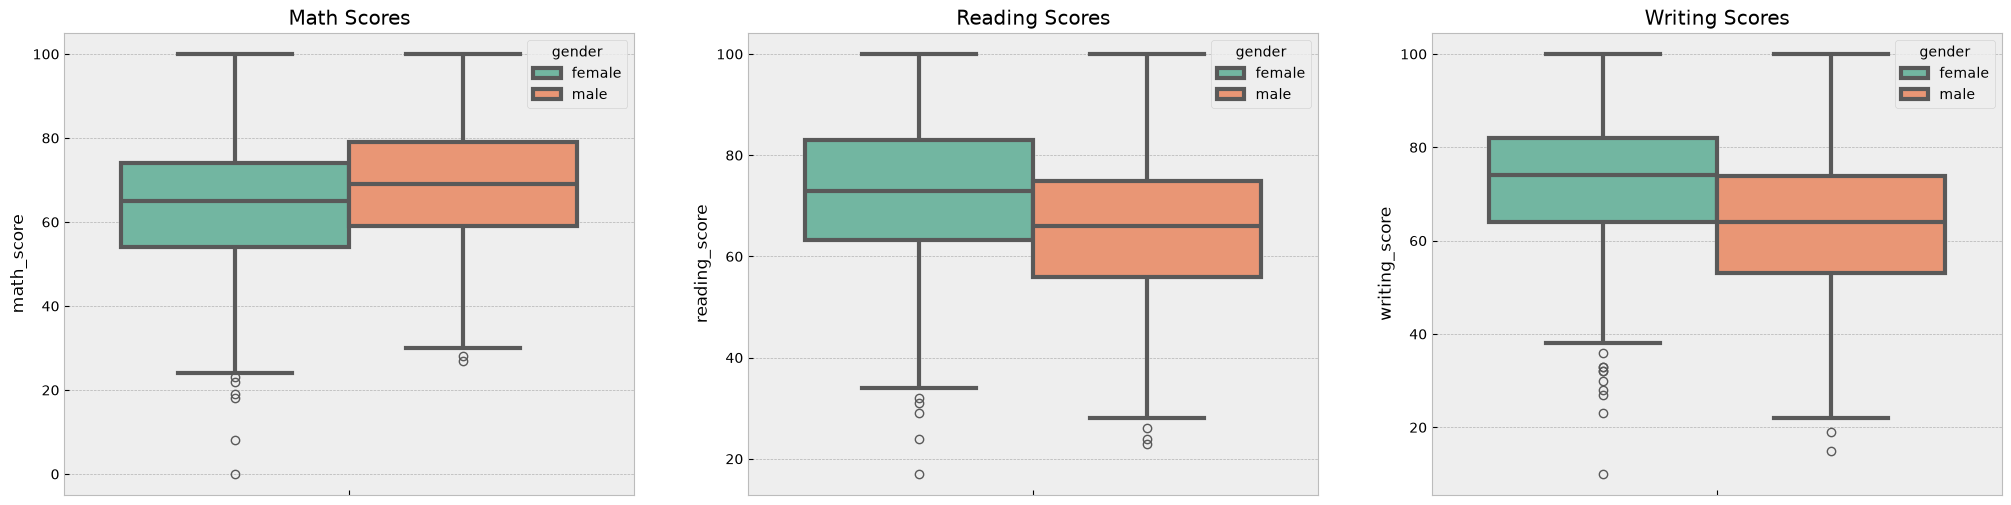

In [18]:
# Displaying the maximum marks oof students in all 3 subjects
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

# For Math
plt.subplot(1, 3, 1)
plt.title('Math Scores')
ax = sns.boxplot(data=df, y='math_score', palette='Set2', linewidth=3, color='red', hue='gender')

# For Reading
plt.subplot(1, 3, 2)
plt.title('Reading Scores')
ax = sns.boxplot(data=df, y='reading_score', palette='Set2', linewidth=3, color='blue', hue='gender')

# For Writing
plt.subplot(1, 3, 3)
plt.title('Writing Scores')
ax = sns.boxplot(data=df, y='writing_score', palette='Set2', linewidth=3, color='green', hue='gender')

plt.show()

## Insights
- male students get around 60 - 80 marks in maths whereas female students get around 55 - 75 marks.
- male students get around 55 - 75 marks in reading whereas female students get around 65 - 85 marks.
- male students get around 50 - 75 marks in writing whereas female students get around 65 - 85 marks.

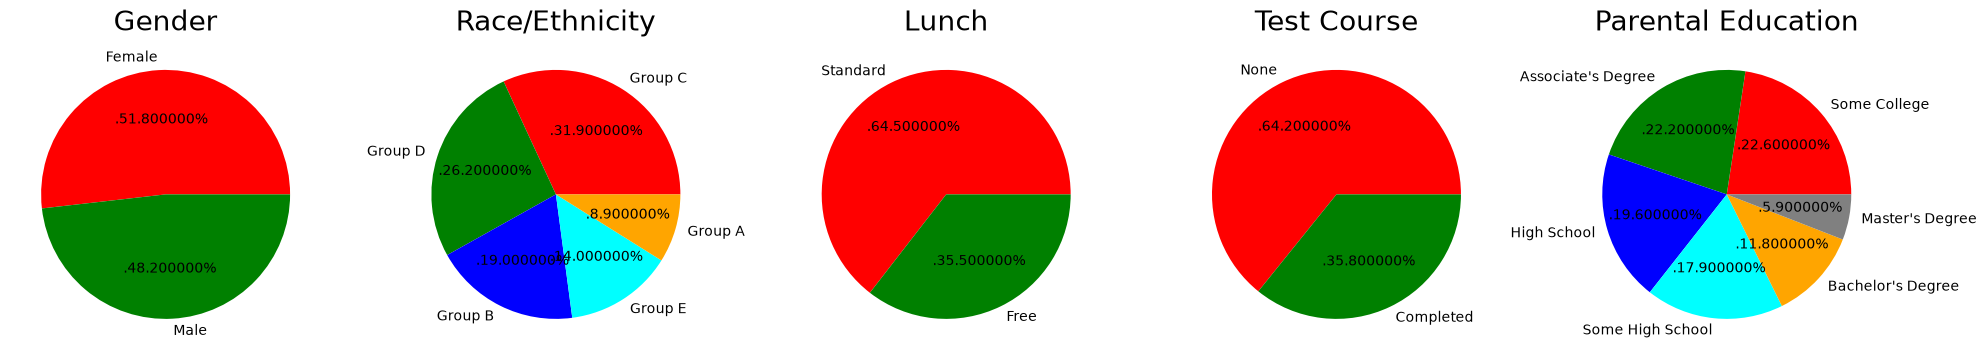

In [19]:
# Multivariable analysis of the dataset using pie charts
plt.subplots(1, 5, figsize=(20, 6))

# Based on gender
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

# Based on race/ethnicity
plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = ['Group C', 'Group D','Group B','Group E','Group A']
color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')

# Based on lunch type
plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free']
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

# Based on test preparation course
plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = ['None', 'Completed']
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')

# Based on parental level of education
plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = ['Some College', "Associate's Degree", 'High School', 'Some High School', "Bachelor's Degree", "Master's Degree"]
color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']
plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()

## Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

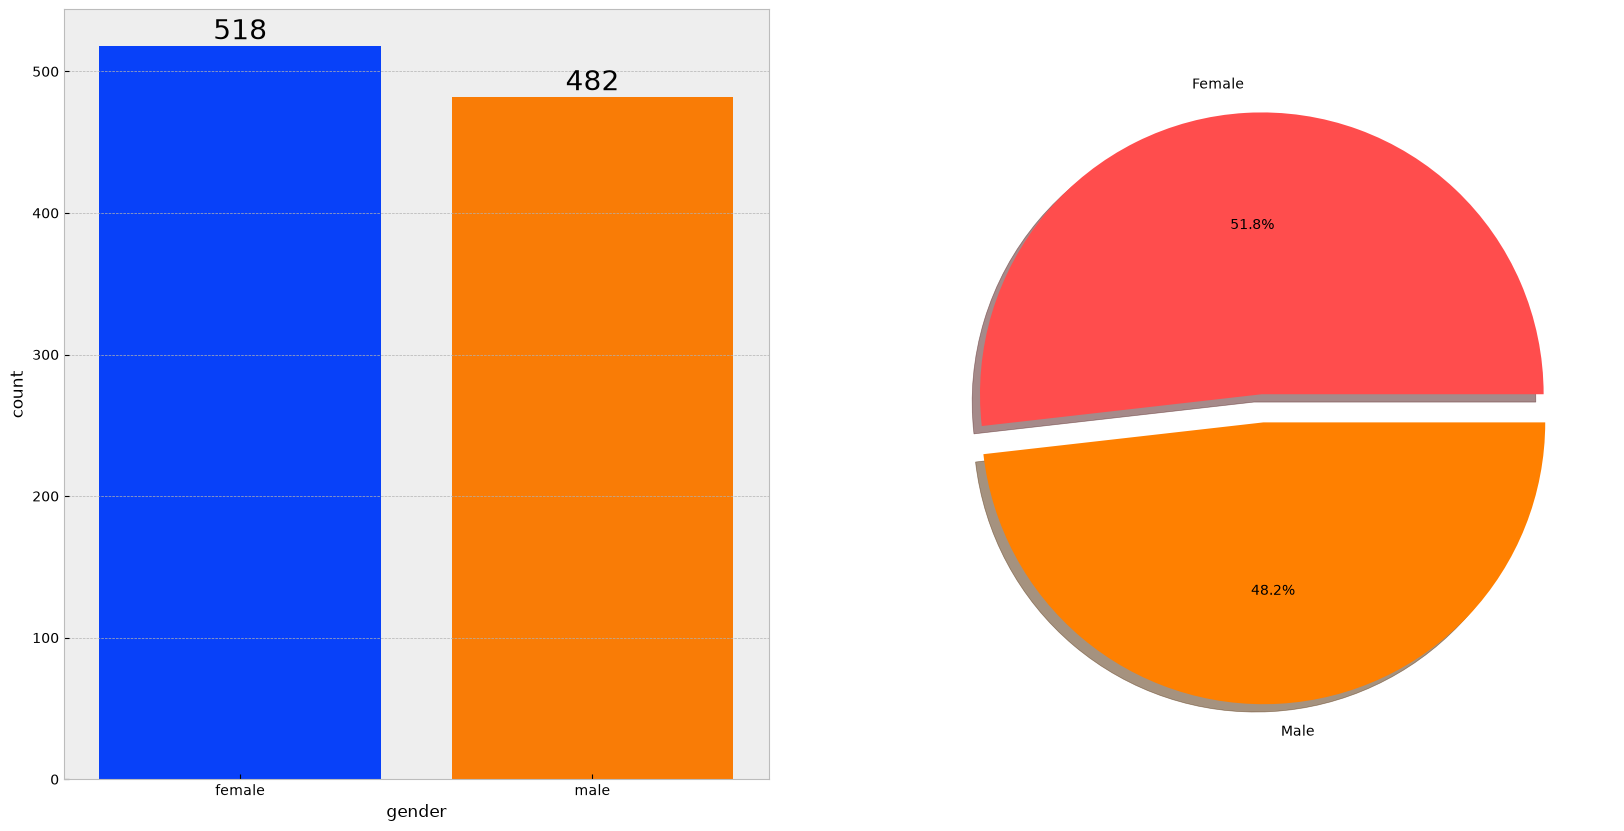

In [24]:
# Univariate analysis of the dataset based on gender
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(x=df['gender'], data=df, hue='gender', palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
    
plt.pie(
    x=df['gender'].value_counts(),
    labels=['Female', 'Male'],
    explode=[0, 0.1],
    autopct='%1.1f%%',
    shadow=True,
    colors=['#ff4d4d', '#ff8000'])

plt.show()

## Insights
- Gender has a balanced data of 482(48.2%) male students and 518(51.8%) female students.

In [29]:
# Bivariate Analysis of the dataset based on gender
gender_group = df.groupby('gender')[['math_score', 'reading_score', 'writing_score', 'total_score', 'average']].mean()
gender_group

,math_score,reading_score,writing_score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837303


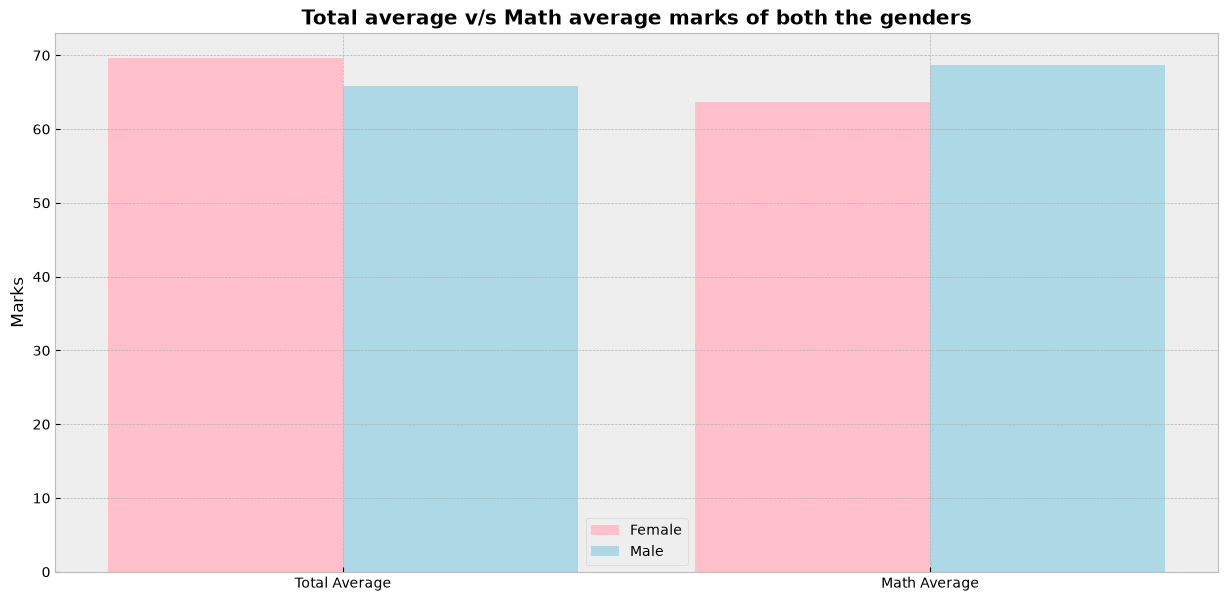

In [30]:
import numpy as np

# Plotting the gender comparison based on average scores and math scores
plt.figure(figsize=(15, 7))

X = ["Total Average", "Math Average"]
female_avg = [gender_group.loc['female', 'average'], gender_group.loc['female', 'math_score']]
male_avg = [gender_group.loc['male', 'average'], gender_group.loc['male', 'math_score']]

X_axis = np.arange(len(X))
plt.bar(X_axis - 0.2, female_avg, 0.4, label='Female', color='pink')
plt.bar(X_axis + 0.2, male_avg, 0.4, label='Male', color='lightblue')

plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.legend()

plt.show()

## Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

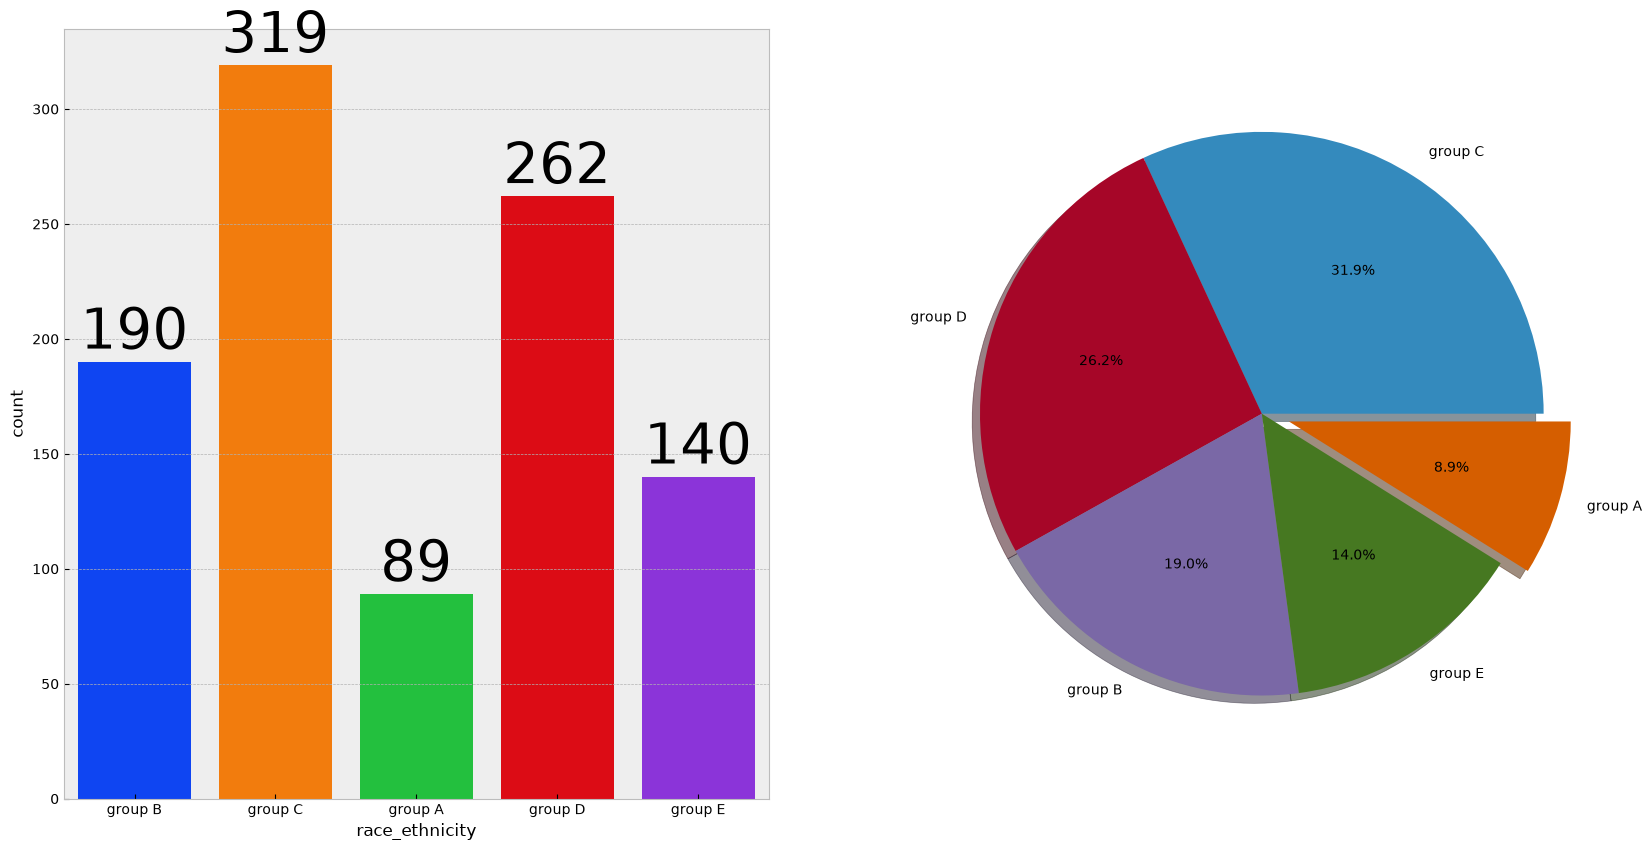

In [32]:
# Univariate analysis of the dataset based on race/ethnicity
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(
    x=df['race_ethnicity'],
    data=df,
    hue='race_ethnicity',
    palette='bright',
    ax=ax[0],
    saturation=0.9
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=40)

plt.pie(
    x=df['race_ethnicity'].value_counts(),
    labels=df["race_ethnicity"].value_counts().index,
    explode=[0, 0, 0, 0, 0.1],
    autopct='%1.1f%%',
    shadow=True
)

plt.show()

## Insights 
- Most of the student belonging from group C or, group D.
- Lowest number of students belong to group A.

In [35]:
# Bivariate Analysis of the dataset based on race/ethnicity
race_group = df.groupby('race_ethnicity')[['math_score', 'reading_score', 'writing_score', 'total_score', 'average']].mean()
race_group

,math_score,reading_score,writing_score,total_score,average
race_ethnicity,,,,,
group A,61.629213,64.674157,62.674157,188.977528,62.992135
group B,63.452632,67.352632,65.600000,196.405263,65.468579
group C,64.463950,69.103448,67.827586,201.394984,67.131567
group D,67.362595,70.030534,70.145038,207.538168,69.179389
group E,73.821429,73.028571,71.407143,218.257143,72.752000


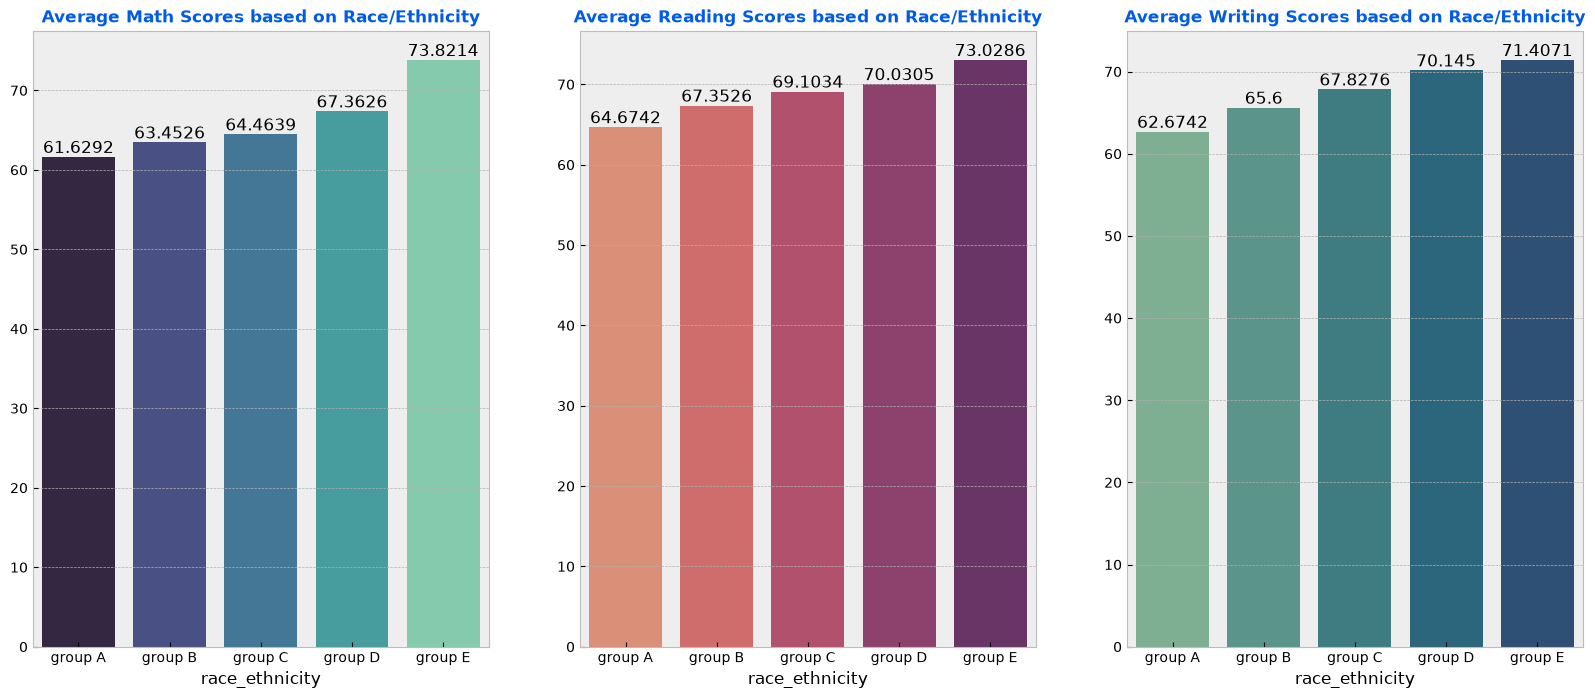

In [46]:
# Plotting the average scores of students based on race/ethnicity
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

# Average Math Scores based on Race/Ethnicity
sns.barplot(
    y=race_group["math_score"].values,
    x=race_group["math_score"].index,
    hue=race_group["math_score"].index,
    palette="mako",
    ax=ax[0],
    legend=False
)
ax[0].set_title(
    "Average Math Scores based on Race/Ethnicity",
    color='#005ce6',
    fontsize=12,
    fontweight='bold'
)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=12)
    
# Average Reading Scores based on Race/Ethnicity
sns.barplot(
    y=race_group["reading_score"].values,
    x=race_group["reading_score"].index,
    hue=race_group["reading_score"].index,
    palette="flare",
    ax=ax[1],
    legend=False
)
ax[1].set_title(
    "Average Reading Scores based on Race/Ethnicity",
    color='#005ce6',
    fontsize=12,
    fontweight='bold'
)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=12)

# Average Writing Scores based on Race/Ethnicity
sns.barplot(
    y=race_group["writing_score"].values,
    x=race_group["writing_score"].index,
    hue=race_group["writing_score"].index,
    palette="crest",
    ax=ax[2],
    legend=False
)
ax[2].set_title(
    "Average Writing Scores based on Race/Ethnicity",
    color='#005ce6',
    fontsize=12,
    fontweight='bold'
)
for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=12)

plt.show()

## Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects.

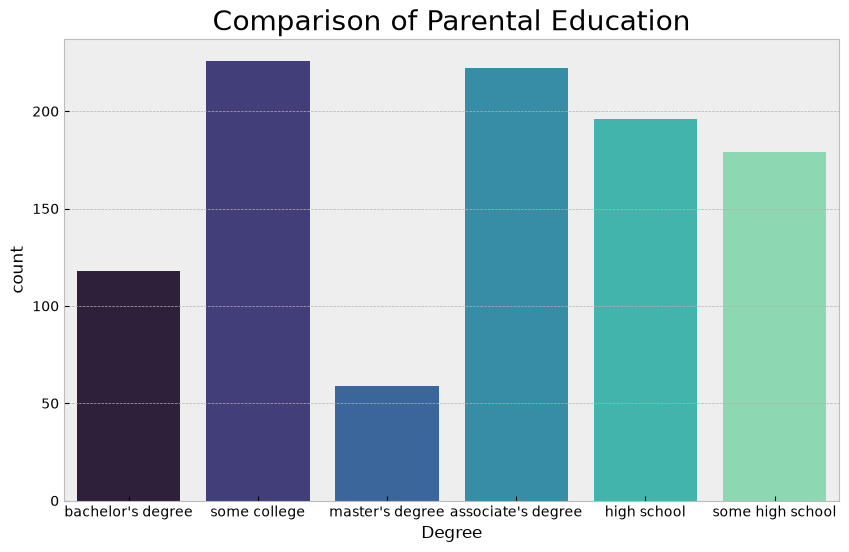

In [51]:
# Univariate analysis of the dataset based on parental level of education
plt.rcParams["figure.figsize"] = (10, 6)

sns.countplot(
    data=df,
    x=df['parental_level_of_education'],
    hue='parental_level_of_education',
    palette='mako',
    saturation=0.95
)
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')

plt.show()

## Insights 
- Largest number of parents are from some college.

In [52]:
# Bivariate Analysis of the dataset based on parental level of education
parent_group = df.groupby('parental_level_of_education')[['math_score', 'reading_score', 'writing_score', 'total_score', 'average']].mean()
parent_group

,math_score,reading_score,writing_score,total_score,average
parental_level_of_education,,,,,
associate's degree,67.882883,70.927928,69.896396,208.707207,69.568964
bachelor's degree,69.389831,73.000000,73.381356,215.771186,71.923983
high school,62.137755,64.704082,62.448980,189.290816,63.097194
master's degree,69.745763,75.372881,75.677966,220.796610,73.598644
some college,67.128319,69.460177,68.840708,205.429204,68.476106
some high school,63.497207,66.938547,64.888268,195.324022,65.107654


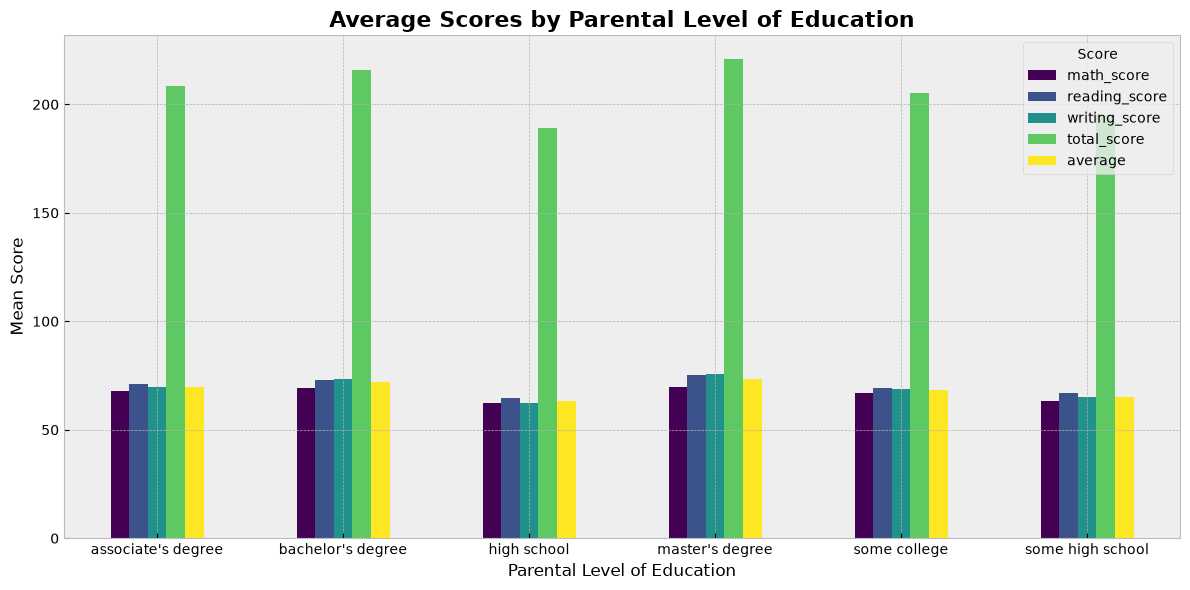

In [65]:
# Visualize average scores by parental level of education
ax = parent_group.plot(kind='bar', figsize=(12, 6), colormap='viridis')

ax.set_title('Average Scores by Parental Level of Education', fontsize=16, fontweight='bold')
ax.set_xlabel('Parental Level of Education')
ax.set_ylabel('Mean Score')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Score')

plt.tight_layout()
plt.show()

## Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

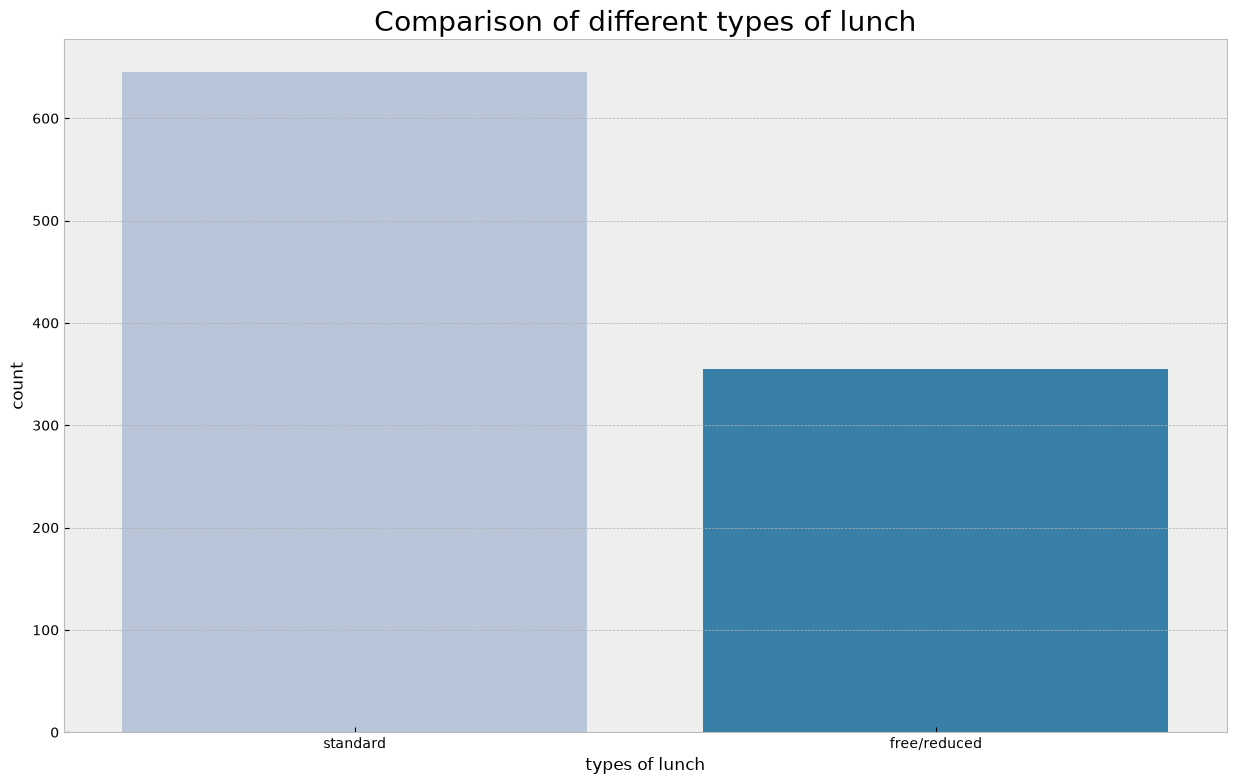

In [67]:
# Univariate analysis of the dataset based on lunch type
plt.rcParams['figure.figsize'] = (15, 9)

sns.countplot(
    data=df,
    x='lunch',
    hue='lunch',
    palette='PuBu',
    legend=False
)
plt.title(
    'Comparison of different types of lunch',
    fontweight=30,
    fontsize=20
)
plt.xlabel('types of lunch')
plt.ylabel('count')

plt.show()

## Insights 
- Students being served Standard lunch was more than free lunch

In [68]:
# Bivariate Analysis of the dataset based on lunch type
lunch_group = df.groupby('lunch')[['math_score', 'reading_score', 'writing_score', 'total_score', 'average']].mean()
lunch_group

,math_score,reading_score,writing_score,total_score,average
lunch,,,,,
free/reduced,58.921127,64.653521,63.022535,186.597183,62.198986
standard,70.034109,71.654264,70.823256,212.511628,70.837116


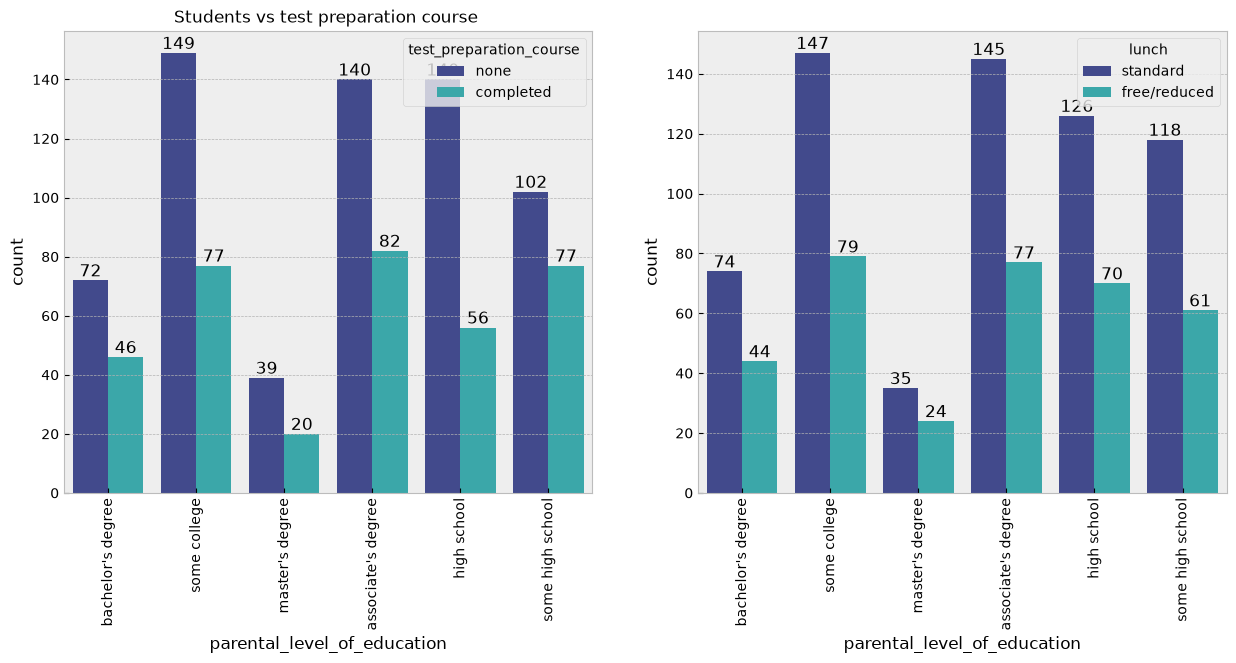

In [71]:
# Plotting the bivariate analysis of the dataset based on parental level of education
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(
    data=df,
    x=df['parental_level_of_education'],
    palette='mako',
    hue='test_preparation_course',
    saturation=0.95,
    ax=ax[0]
)
ax[0].set_title('Students vs test preparation course ', color='black', size=12)
ax[0].tick_params(axis='x', rotation=90)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=12)
    
sns.countplot(
    data=df,
    x=df['parental_level_of_education'],
    palette='mako',
    hue='lunch',
    saturation=0.95,
    ax=ax[1]
)
ax[1].tick_params(axis='x', rotation=90)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=12)

plt.show()

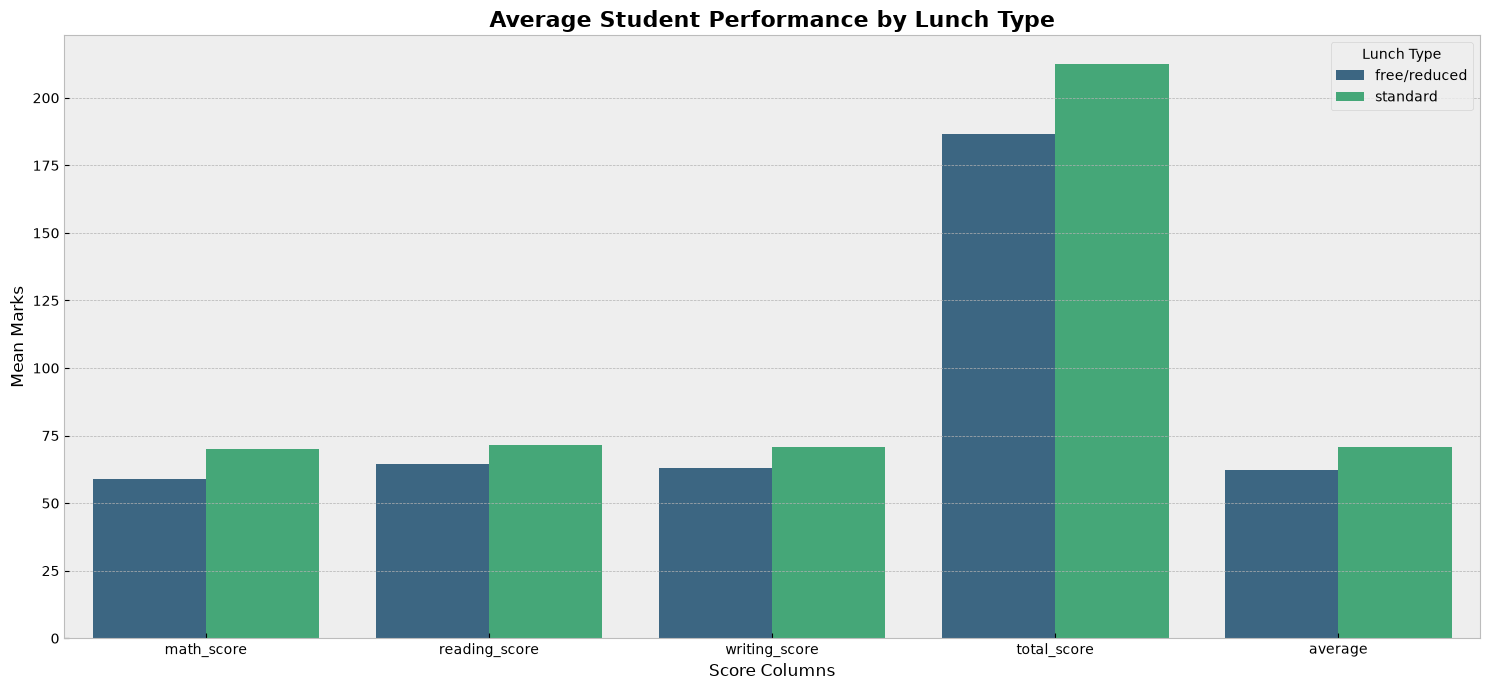

In [77]:
# Plotting performance comparison of students based on lunch type
lunch_plot_data = lunch_group.T.reset_index()
lunch_plot_data = lunch_plot_data.rename(columns={'index': 'marks'})
lunch_plot_data = lunch_plot_data.melt(
    id_vars='marks',
    var_name='lunch',
    value_name='mean_score'
)

plt.figure(figsize=(15, 7))
sns.barplot(
    data=lunch_plot_data,
    x='marks',
    y='mean_score',
    hue='lunch',
    palette='viridis'
)

plt.title('Average Student Performance by Lunch Type', fontsize=16, fontweight='bold')
plt.xlabel('Score Columns')
plt.ylabel('Mean Marks')
plt.legend(title='Lunch Type')
plt.tight_layout()
plt.show()

## Insights
- Standard lunch is better for student performances.

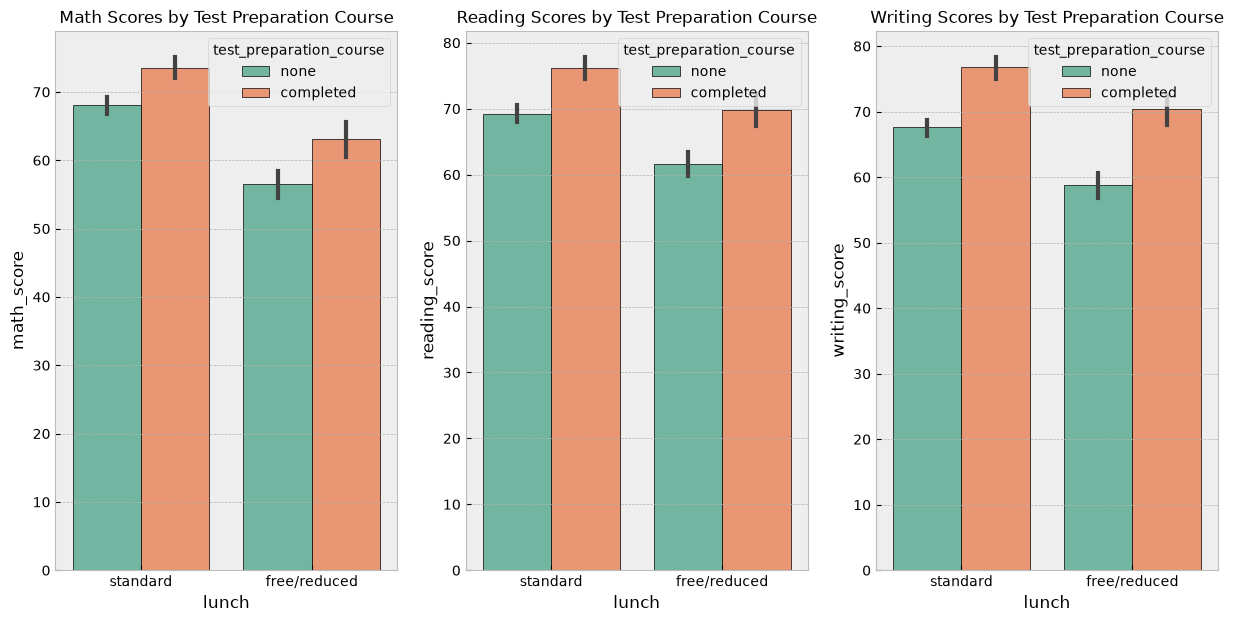

In [80]:
# Bivariate Analysis of the impact of test preparation course on student performance
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.title('Math Scores by Test Preparation Course', size=12)
sns.barplot(
    data=df,
    x='lunch',
    y='math_score',
    hue='test_preparation_course',
    palette='Set2',
    edgecolor='black'
)

plt.subplot(1, 3, 2)
plt.title('Reading Scores by Test Preparation Course', size=12)
sns.barplot(
    data=df,
    x='lunch',
    y='reading_score',
    hue='test_preparation_course',
    palette='Set2',
    edgecolor='black'
)

plt.subplot(1, 3, 3)
plt.title('Writing Scores by Test Preparation Course', size=12)
sns.barplot(
    data=df,
    x='lunch',
    y='writing_score',
    hue='test_preparation_course',
    palette='Set2',
    edgecolor='black'
)

plt.show()

## Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course.

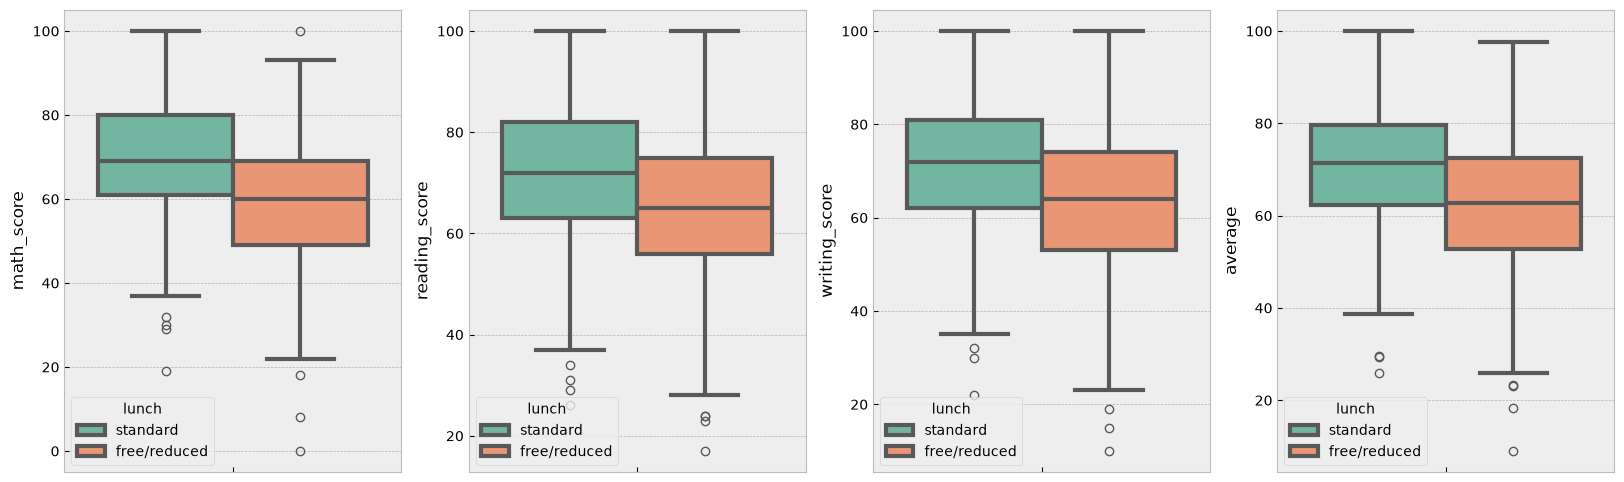

In [83]:
# Checking for the outliers
plt.subplots(1, 4, figsize=(20, 6))

# For Math Scores
plt.subplot(1, 4, 1)
sns.boxplot(data=df, y='math_score', hue="lunch", palette='Set2', linewidth=3, color='red',)

# For Reading Scores
plt.subplot(1, 4, 2)
sns.boxplot(data=df, y='reading_score', hue="lunch", palette='Set2', linewidth=3, color='blue',)

# For Writing Scores
plt.subplot(1, 4, 3)
sns.boxplot(data=df, y='writing_score', hue="lunch", palette='Set2', linewidth=3, color='green')

# For Average Scores
plt.subplot(1, 4, 4)
sns.boxplot(data=df, y='average', hue="lunch", palette='Set2', linewidth=3, color='orange')

plt.show()

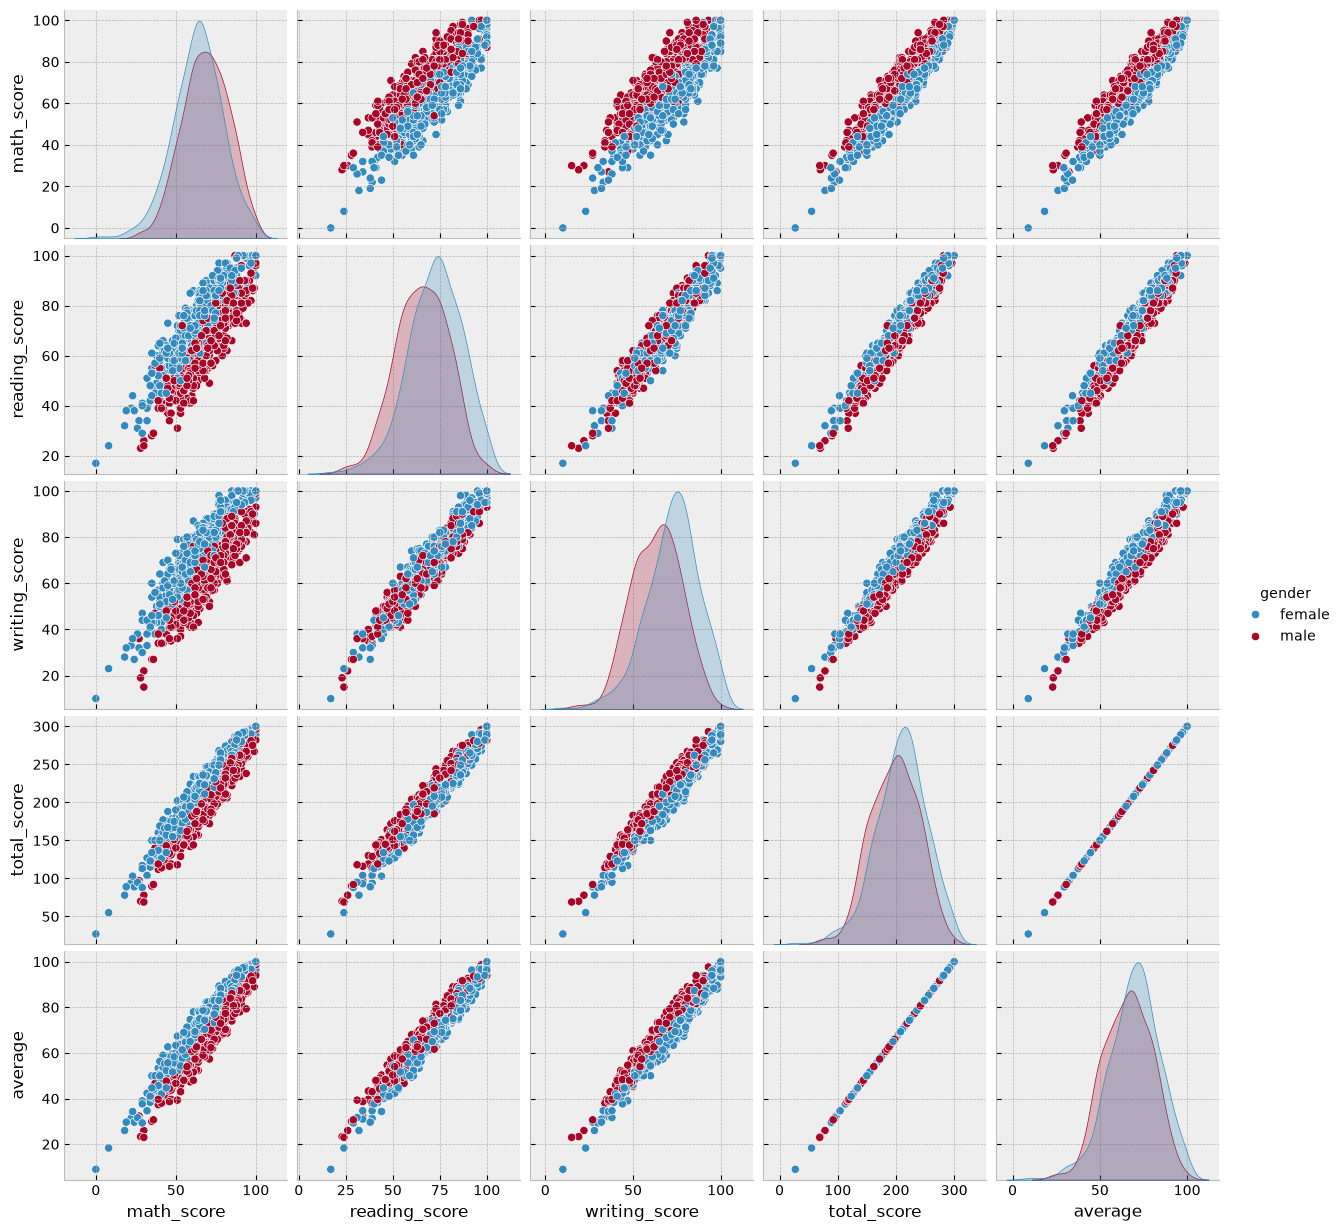

In [84]:
# Multivariate Analysis by using pairplot
sns.pairplot(data=df, hue="gender")
plt.show()

## Insights
- From the above plot it is clear that all the scores increase linearly with each other.

## Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.